<a href="https://colab.research.google.com/github/djcd171117/TERMINAL-III/blob/main/Evaluaci%C3%B3n%201/Evaluacion%201_Terminal%20de%20Economia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DINÁMICA DE LIQUIDEZ HIPOTECARIA Y RIESGO DE COLOCACIÓN EN LA ZM DE QUERÉTARO.**



Descarga e integración de archivos históricos 2019-2025 de líquidez hipotecaria desde directorio de Github

Enlace de descarga desde portal https://sniiv.sedatu.gob.mx/Reporte/Datos_abiertos

In [17]:
import pandas as pd
import zipfile
import re
import os
import urllib.request

# =====================================================================
# 1. RUTA RELATIVA
# =====================================================================
ruta_zip = '../historico_liquidez_19-25.zip'

# =====================================================================
# 2. ENLACE DE REPOSITORIO DE GITHUB CON GOOGLE COLAB
# =====================================================================
if not os.path.exists(ruta_zip):
    print("Entorno Google colab detectado")
    print("Descargando el archivo ZIP directamente desde GitHub...")

    # Creamos la carpeta temporal para Colab
    os.makedirs('../Datos', exist_ok=True)

    # URL enlace de archivo RAW de repositorio
    url_raw_github = 'https://github.com/djcd171117/TERMINAL-III/raw/refs/heads/main/Evaluaci%C3%B3n%201/historico_liquidez_19-25.zip'

    # Descargamos el archivo
    urllib.request.urlretrieve(url_raw_github, ruta_zip)
    print("Descarga exitosa. Listo para procesar.")


datasets = []
print("\n--- Iniciando extracción y consolidación en memoria ---")

# =====================================================================
# 3. EXTRACCIÓN Y LECTURA EN MEMORIA
# =====================================================================
with zipfile.ZipFile(ruta_zip, 'r') as archivo_zip:
    archivos_csv = [f for f in archivo_zip.namelist() if f.endswith('.csv')]
    print(f"Archivos detectados en el ZIP: {len(archivos_csv)}\n")

    for nombre_archivo in archivos_csv:
        with archivo_zip.open(nombre_archivo) as file:
            try:
                df_temp = pd.read_csv(file, encoding='latin-1', low_memory=False)
            except:
                file.seek(0)
                df_temp = pd.read_csv(file, encoding='utf-8-sig', low_memory=False)

        # --- FASE DE LIMPIEZA ---
        df_temp.columns = df_temp.columns.str.lower().str.strip().str.replace(' ', '_')
        df_temp.columns = df_temp.columns.str.replace('ñ', 'n').str.replace('á', 'a').str.replace('é', 'e')

        df_temp['cve_ent'] = pd.to_numeric(df_temp['cve_ent'], errors='coerce').astype('Int64').astype(str).str.zfill(2)
        df_temp['cve_mun'] = pd.to_numeric(df_temp['cve_mun'], errors='coerce').astype('Int64').astype(str).str.zfill(3)

        df_temp = df_temp[df_temp['destino'] == 2].copy()

        col_anio = [c for c in df_temp.columns if 'ano' in c or 'año' in c]

        if col_anio:
            df_temp['año_analisis'] = pd.to_numeric(df_temp[col_anio[0]], errors='coerce').astype('Int64')
        else:
            anio_extraido = re.search(r'\d{4}', os.path.basename(nombre_archivo))
            df_temp['año_analisis'] = int(anio_extraido.group()) if anio_extraido else 0

        datasets.append(df_temp)

# =====================================================================
# 4. FUSIÓN Y GUARDADO EN UN SÓLO ARCHIVO
# =====================================================================
if datasets:
    df_historico = pd.concat(datasets, axis=0, ignore_index=True)
    df_historico['monto'] = pd.to_numeric(df_historico['monto'], errors='coerce').fillna(0)
    df_historico['acciones'] = pd.to_numeric(df_historico['acciones'], errors='coerce').fillna(0)

    ruta_salida = '../Datos/master_historico_qro.csv'
    os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)
    df_historico.to_csv(ruta_salida, index=False)

    print(f"--- ÉXITO: {df_historico.shape[0]} registros consolidados ---")
else:
    print("No se encontraron archivos válidos.")


--- Iniciando extracción y consolidación en memoria ---
Archivos detectados en el ZIP: 7

--- ÉXITO: 819583 registros consolidados ---


  **En este bloque transformamos los datos del archivo histórico:**


In [31]:
# =====================================================================
# LIMPIEZA
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

# 1. Tomamos el dataFrame de la extracción original
df_base = df_historico.copy()

# 2. Limpieza estructural
df_base['cve_ent'] = pd.to_numeric(df_base['cve_ent'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(2)
df_base['cve_mun'] = pd.to_numeric(df_base['cve_mun'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(3)
df_base['monto'] = pd.to_numeric(df_base['monto'], errors='coerce').fillna(0)
df_base['acciones'] = pd.to_numeric(df_base['acciones'], errors='coerce').fillna(0)

# 3. Filtramos solo Querétaro para el resto del notebook
df_qro = df_base[df_base['cve_ent'] == '22'].copy()

# 4. Variables globales
foco_codes = ['014', '011', '006', '016']
mapa_nombres = {'014': 'Querétaro', '011': 'El Marqués', '006': 'Corregidora', '016': 'San Juan del Río'}
paleta_jerarquia = {'Querétaro': '#0A2540', 'El Marqués': '#635BFF', 'Corregidora': '#FF3B30', 'San Juan del Río': '#00D4FF'}



**Verificación de ciclos anuales completos para evitar sesgos estacionales.**

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


brecha = df_q[df_q['cve_mun'].isin(foco_codes)].groupby(['año_analisis', 'cve_mun']).agg(
    precio_promedio=('monto', 'mean'),
    ingreso_promedio=('ingresos_rango', 'mean')
).reset_index()



# ==============================================================================
# 1. Auditoría de meses por año
# ==============================================================================

auditoria = df_historico.groupby('año_analisis').agg(
    meses_registrados=('mes', 'nunique'),
    ultimo_mes=('mes', 'max'),
    total_acciones=('acciones', 'sum')
).reset_index()

print("--- REVISIÓN DE INTEGRIDAD TEMPORAL ---")
print(auditoria.to_string(index=False))


--- REVISIÓN DE INTEGRIDAD TEMPORAL ---
 año_analisis  meses_registrados  ultimo_mes  total_acciones
         2019                 12          12        315384.0
         2020                 12          12        298744.0
         2021                 12          12        284560.0
         2022                 12          12        278244.0
         2023                 12          12        247909.0
         2024                 12          12        249510.0
         2025                 11          11        208463.0


**Asequibilidad ZMQ: Índice de Esfuerzo Financiero en los principales núcleos urbanos.**

/tmp/ipykernel_1544/787300358.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_esfuerzo = df_esfuerzo.groupby('municipio', group_keys=False).apply(calcular_porcentaje_esfuerzo)


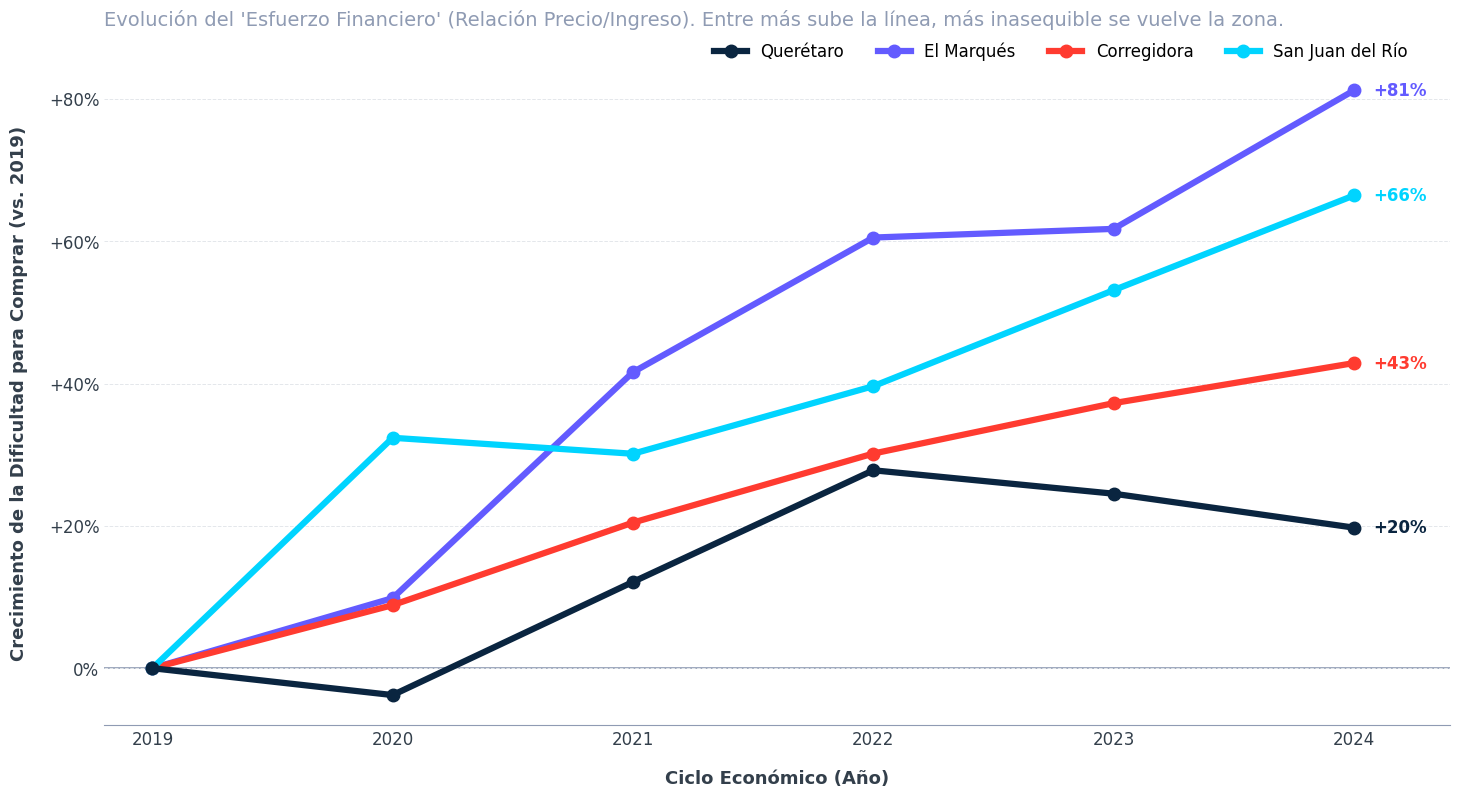

In [33]:
# ==============================================================================
# CÁLCULO DE ÍNDICE DE ESFUERZO
# ==============================================================================

# Filtro de representatividad: Excluimos 2025 para asegurar ciclos anuales completos
df_esfuerzo = brecha[brecha['año_analisis'] <= 2024].copy()
df_esfuerzo['municipio'] = df_esfuerzo['cve_mun'].map(mapa_nombres)

# Cálculo del Ratio de Esfuerzo Absoluto
df_esfuerzo['esfuerzo_absoluto'] = df_esfuerzo['precio_promedio'] / df_esfuerzo['ingreso_promedio']

# Normalización a Base 100 (Crecimiento respecto a 2019)
def calcular_porcentaje_esfuerzo(group):
    base_esfuerzo = group.loc[group['año_analisis'] == 2019, 'esfuerzo_absoluto'].values[0]
    group['pct_crecimiento'] = ((group['esfuerzo_absoluto'] / base_esfuerzo) - 1) * 100
    return group

df_esfuerzo = df_esfuerzo.groupby('municipio', group_keys=False).apply(calcular_porcentaje_esfuerzo)

# ==============================================================================
# VISUALIZACIÓN DE ASEQUIBILIDAD
# ==============================================================================
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(15, 8.5), facecolor='white')
ax.set_facecolor('white')

ax.grid(axis='y', color='#E4E7EB', linestyle='--', linewidth=0.7, zorder=0)
for spine in ['top', 'right', 'left']: ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#8F9BB3')

ax.axhline(0, color='#8F9BB3', linewidth=1.2, linestyle='-', zorder=1)

# Graficamos
for mun in ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']:
    data = df_esfuerzo[df_esfuerzo['municipio'] == mun].sort_values('año_analisis')
    if data.empty: continue

    ax.plot(data['año_analisis'], data['pct_crecimiento'], marker='o', markersize=9, linewidth=4.5,
            label=mun, color=paleta_jerarquia[mun], zorder=4 if mun == 'Querétaro' else 3)

    ultimo_año = data['año_analisis'].iloc[-1]
    ultimo_val = data['pct_crecimiento'].iloc[-1]
    signo = "+" if ultimo_val > 0 else ""
    ax.text(ultimo_año + 0.08, ultimo_val, f"{signo}{ultimo_val:.0f}%",
            color=paleta_jerarquia[mun], fontweight='bold', fontsize=12, va='center')

# Ejes
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{'+' if x > 0 else ''}{x:.0f}%" if x != 0 else "0%"))
ax.set_ylabel("Crecimiento de la Dificultad para Comprar (vs. 2019)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)
ax.set_xlabel("Ciclo Económico (Año)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)
ax.tick_params(axis='both', labelsize=12, colors='#333F4B', length=0)
ax.set_xticks(range(2019, 2025))
ax.set_xlim(2018.8, 2024.4)

plt.title("Evolución del 'Esfuerzo Financiero' (Relación Precio/Ingreso). Entre más sube la línea, más inasequible se vuelve la zona.",
          fontsize=14, color='#8F9BB3', loc='left', pad=25)

plt.legend(bbox_to_anchor=(0.98, 1.05), loc='upper right', frameon=False, fontsize=12, ncol=4)
plt.tight_layout(rect=[0, 0, 0.98, 0.95])
plt.show()

**Volumen de absorción en el arranque de ciclo de enero**

In [34]:
# ==============================================================================
# ANÁLISIS DE COYUNTURA: COMPARATIVA DE ENEROS (ARRANQUE DE CICLO)
# ==============================================================================

# Filtro estacional (Enero)
df_eneros = df_qro[df_qro['mes'] == 1].copy()

# Métricas de apertura interanual
tendencia_enero = df_eneros.groupby('año_analisis').agg(
    acciones_enero=('acciones', 'sum'),
    capital_enero=('monto', 'sum'),
    ticket_enero=('monto', 'mean')
).reset_index()

# Cálculo de variación porcentual
tendencia_enero['crecimiento_volumen'] = tendencia_enero['acciones_enero'].pct_change() * 100

print("--- COMPARATIVA ESTRATÉGICA: ENERO 2019 VS ENERO 2025 ---")
print(tendencia_enero.to_string(index=False))

--- COMPARATIVA ESTRATÉGICA: ENERO 2019 VS ENERO 2025 ---
 año_analisis  acciones_enero  capital_enero  ticket_enero  crecimiento_volumen
         2019           700.0   6.357482e+08  1.704419e+06                  NaN
         2020           843.0   7.784122e+08  1.990824e+06            20.428571
         2021           720.0   7.114617e+08  1.922869e+06           -14.590747
         2022           737.0   8.244792e+08  2.258847e+06             2.361111
         2023           690.0   8.775900e+08  2.651329e+06            -6.377205
         2024           911.0   1.150572e+09  2.833921e+06            32.028986
         2025           382.0   5.302050e+08  2.335705e+06           -58.068057


**Gráfica de precios y desplazamiento histórico de la barrera de entrada hipotecaria.**

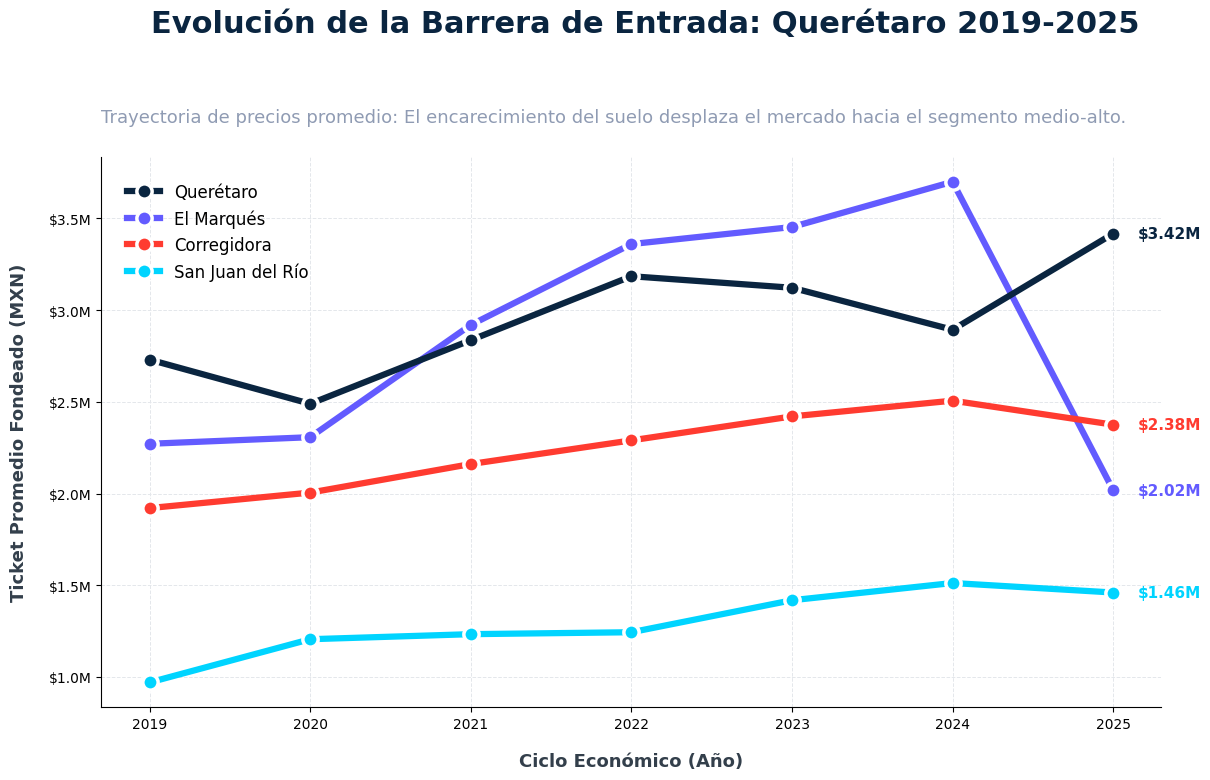

In [35]:
# ==============================================================================
# AGRUPACIÓN DE TRAYECTORIA (TICKET PROMEDIO)
# ==============================================================================

historico = df_qro[df_qro['cve_mun'].isin(foco_codes)].groupby(['año_analisis', 'cve_mun']).agg(
    ticket_promedio=('monto', 'mean')
).reset_index()

historico['municipio_nombre'] = historico['cve_mun'].map(mapa_nombres)

# ==============================================================================
# VISUALIZACIÓN DE BARRERA DE ENTRADA
# ==============================================================================

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')
ax.set_facecolor('white')
ax.grid(color='#E4E7EB', linestyle='--', linewidth=0.7, zorder=0)

# Graficamos
for mun in ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']:
    data = historico[historico['municipio_nombre'] == mun].sort_values('año_analisis')
    if data.empty: continue

    ax.plot(data['año_analisis'], data['ticket_promedio'],
            color=paleta_jerarquia[mun], linewidth=4.5, marker='o',
            markersize=11, markeredgecolor='white', markeredgewidth=2.5,
            label=mun, zorder=5 if mun == 'Querétaro' else 3)

    # Etiqueta de valor final
    ultimo_año = data['año_analisis'].iloc[-1]
    ultimo_val = data['ticket_promedio'].iloc[-1]
    ax.text(ultimo_año + 0.15, ultimo_val, f"${ultimo_val/1e6:.2f}M",
            color=paleta_jerarquia[mun], fontweight='bold', va='center', fontsize=11)

# Formatos de Ejes
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))
ax.set_xticks(range(2019, 2026))
ax.set_xlabel("Ciclo Económico (Año)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)
ax.set_ylabel("Ticket Promedio Fondeado (MXN)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)

# Títulos
plt.suptitle('Evolución de la Barrera de Entrada: Querétaro 2019-2025',
             fontsize=22, fontweight='bold', color='#0A2540', x=0.12, ha='left', y=0.97)
plt.title('Trayectoria de precios promedio: El encarecimiento del suelo desplaza el mercado hacia el segmento medio-alto.',
          fontsize=13, color='#8F9BB3', loc='left', pad=25)

for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.legend(frameon=False, loc='upper left', fontsize=12, bbox_to_anchor=(0.01, 0.98))

plt.tight_layout(rect=[0, 0, 0.94, 0.92])
plt.savefig('trayectoria_historica_premium.png', dpi=300, bbox_inches='tight')
plt.show()

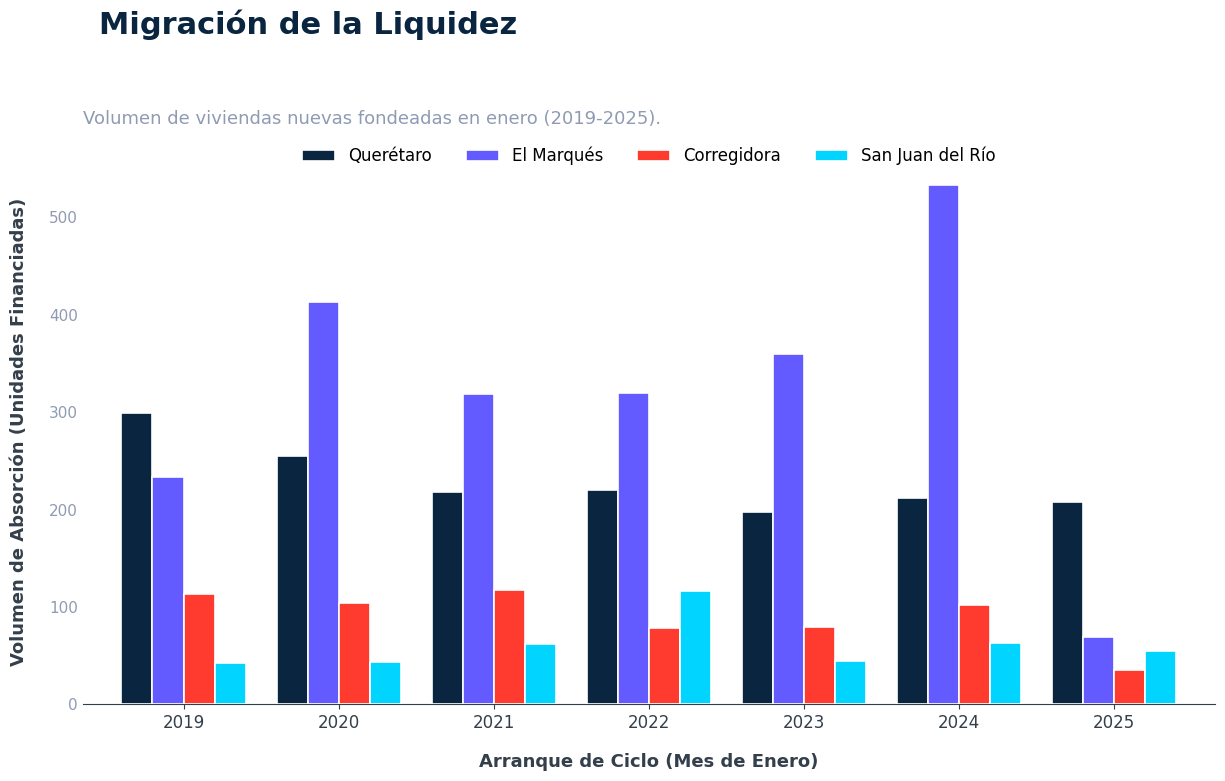

In [37]:
# ==============================================================================
# ANÁLISIS DE ABSORCIÓN: COMPARATIVA DE ENEROS (ARRANQUE DE CICLO)
# ==============================================================================

# Filtro estacional sobre la base de Querétaro
df_eneros = df_qro[df_qro['mes'] == 1].copy()

# Agrupación de Volumen
historico_vol = df_eneros[df_eneros['cve_mun'].isin(foco_codes)].groupby(['año_analisis', 'cve_mun']).agg(
    volumen_casas=('acciones', 'sum')
).reset_index()

historico_vol['municipio_nombre'] = historico_vol['cve_mun'].map(mapa_nombres)

# Transformación para barras agrupadas
df_pivot = historico_vol.pivot(index='año_analisis', columns='municipio_nombre', values='volumen_casas').fillna(0)
orden = ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']
df_pivot = df_pivot[orden]

# ==============================================================================
# VISUALIZACIÓN DE BARRAS
# ==============================================================================
colores_lista = [paleta_jerarquia[m] for m in orden]

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')
ax.set_facecolor('white')
ax.grid(axis='y', color='#E4E7EB', linestyle='--', linewidth=0.7, zorder=0)

# Graficado
df_pivot.plot(kind='bar', color=colores_lista, ax=ax, width=0.8, zorder=3, edgecolor='white', linewidth=1.2)

# Estética de ejes
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#333F4B')

ax.tick_params(axis='y', length=0, labelsize=11, colors='#8F9BB3')
ax.tick_params(axis='x', rotation=0, labelsize=12, colors='#333F4B')

ax.set_xlabel("Arranque de Ciclo (Mes de Enero)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)
ax.set_ylabel("Volumen de Absorción (Unidades Financiadas)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)

# Títulos y Leyenda
plt.suptitle('Migración de la Liquidez', fontsize=22, fontweight='bold', color='#0A2540', x=0.08, ha='left', y=0.97)
plt.title('Volumen de viviendas nuevas fondeadas en enero (2019-2025).', fontsize=13, color='#8F9BB3', loc='left', pad=25)
plt.legend(frameon=False, loc='upper center', fontsize=12, bbox_to_anchor=(0.5, 1.05), ncol=4)

plt.tight_layout(rect=[0, 0, 0.95, 0.92])
plt.savefig('volumen_absorcion_barras.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1544/3377716885.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


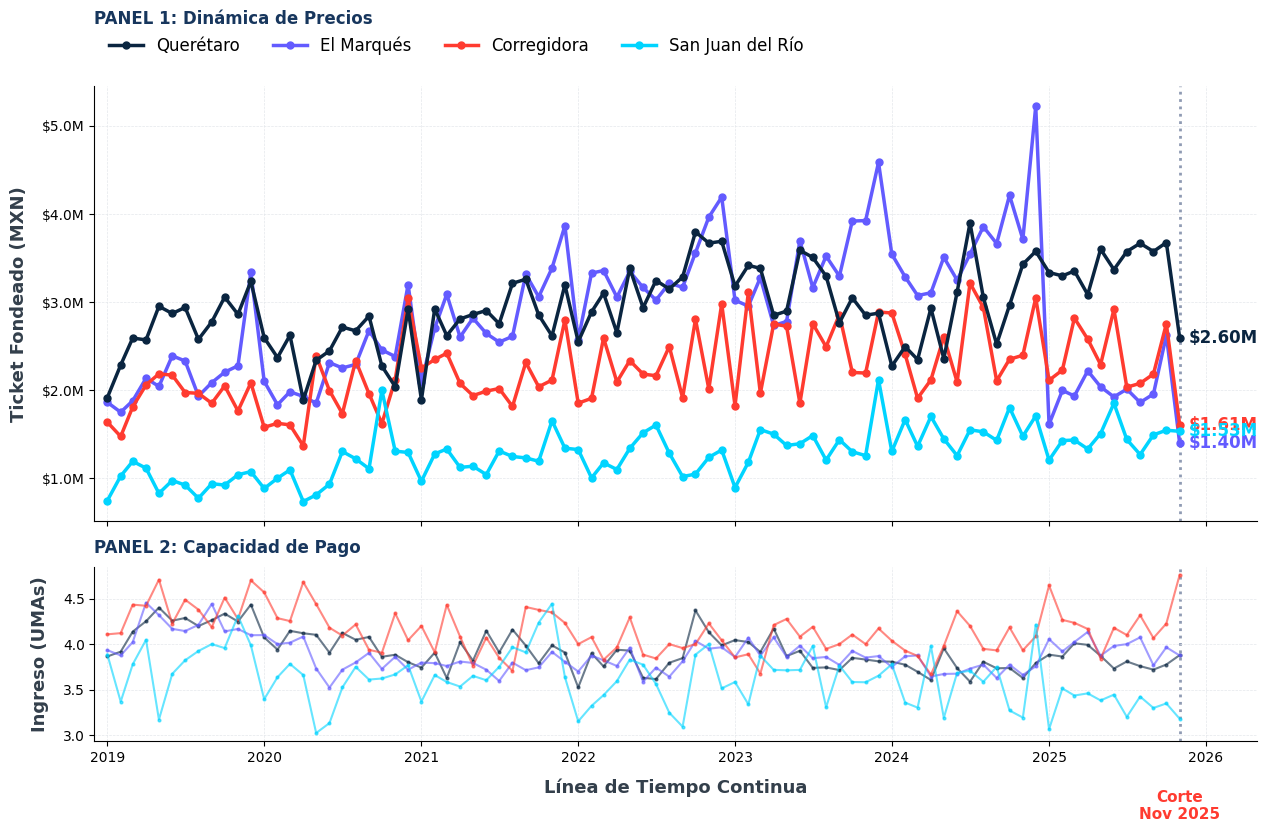

In [38]:
# ==============================================================================
# PROCESAMIENTO DE SERIE TEMPORAL
# ==============================================================================

# # Conversión de serie temporal
df_fechas = df_qro.copy()
df_fechas['fecha'] = pd.to_datetime(df_fechas['año_analisis'].astype(str) + '-' +
                                    df_fechas['mes'].astype(str).str.zfill(2) + '-01', errors='coerce')
df_fechas = df_fechas.dropna(subset=['fecha'])

# Agrupación por fecha y municipio
historico = df_fechas[df_fechas['cve_mun'].isin(foco_codes)].groupby(['fecha', 'cve_mun']).agg(
    ticket_promedio=('monto', 'mean'),
    ingreso_promedio=('ingresos_rango', 'mean')
).reset_index()

historico['municipio_nombre'] = historico['cve_mun'].map(mapa_nombres)

# ==============================================================================
# VISUALIZACIÓN DE TENDENCIAS MACROECONÓMICAS
# ==============================================================================
plt.rcParams['font.family'] = 'sans-serif'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8.5), sharex=True,
                               gridspec_kw={'height_ratios': [2.5, 1], 'hspace': 0.15})
fig.patch.set_facecolor('white')

for ax in [ax1, ax2]:
    ax.set_facecolor('white')
    ax.grid(color='#E4E7EB', linestyle='--', linewidth=0.5, zorder=0)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

ultima_fecha = historico['fecha'].max()

# Panel Superior: Evolución de Precios
for mun in ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']:
    data = historico[historico['municipio_nombre'] == mun].sort_values('fecha')
    if data.empty: continue

    ax1.plot(data['fecha'], data['ticket_promedio'], color=paleta_jerarquia[mun],
             linewidth=2.5, marker='o', markersize=5, label=mun, zorder=5 if mun == 'Querétaro' else 3)

    ultimo_val = data['ticket_promedio'].iloc[-1]
    ax1.text(ultima_fecha + pd.Timedelta(days=20), ultimo_val, f"${ultimo_val/1e6:.2f}M",
             color=paleta_jerarquia[mun], fontweight='bold', va='center', fontsize=12)

ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))
ax1.set_ylabel("Ticket Fondeado (MXN)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=10)
ax1.set_title('PANEL 1: Dinámica de Precios', fontsize=12, color='#17365D', fontweight='bold', loc='left', pad=45)
ax1.legend(frameon=False, loc='upper left', fontsize=12, ncol=4, bbox_to_anchor=(0, 1.15))

# Panel Inferior: Capacidad de Pago
for mun in ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']:
    data = historico[historico['municipio_nombre'] == mun].sort_values('fecha')
    if data.empty: continue
    ax2.plot(data['fecha'], data['ingreso_promedio'], color=paleta_jerarquia[mun],
             linewidth=1.5, linestyle='-', marker='.', markersize=4, alpha=0.6, zorder=3)

ax2.set_ylabel("Ingreso (UMAs)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=10)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_xlabel("Línea de Tiempo Continua", fontsize=13, fontweight='bold', color='#333F4B', labelpad=10)
ax2.set_title('PANEL 2: Capacidad de Pago', fontsize=12, color='#17365D', fontweight='bold', loc='left', pad=10)

# Marca de corte temporal
for ax in [ax1, ax2]:
    ax.axvline(ultima_fecha, color='#8F9BB3', linestyle=':', linewidth=2, zorder=1)

ax2.text(ultima_fecha, ax2.get_ylim()[0] - (ax2.get_ylim()[1]-ax2.get_ylim()[0])*0.28,
         f"Corte\n{ultima_fecha.strftime('%b %Y')}", color='#FF3B30', fontweight='bold', fontsize=11, ha='center', va='top')

ax1.set_xlim(historico['fecha'].min() - pd.Timedelta(days=30), ultima_fecha + pd.Timedelta(days=180))

plt.tight_layout()
plt.savefig('panel_tiempo_panoramico_final.png', dpi=300, bbox_inches='tight')
plt.show()

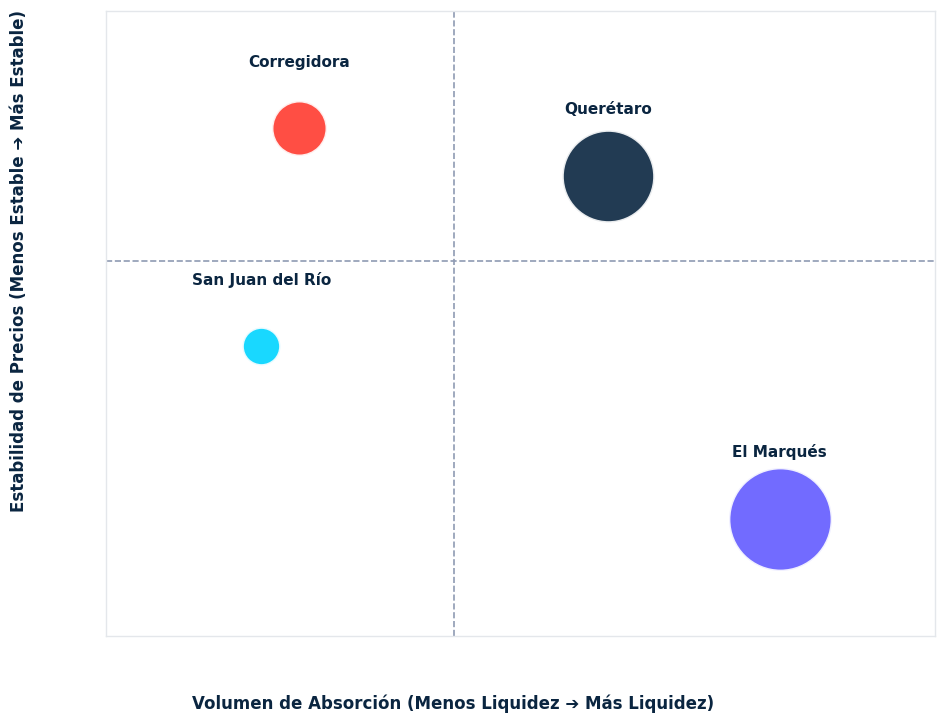

In [39]:
# ==============================================================================
# VOLUMEN Y ESTABILIDAD
# ==============================================================================

# Agrupación base para matriz de dispersión
anual = df_qro[df_qro['cve_mun'].isin(foco_codes)].groupby(['año_analisis', 'cve_mun']).agg(
    ticket_promedio=('monto', 'mean'),
    acciones_totales=('acciones', 'sum'),
    monto_total=('monto', 'sum')
).reset_index()

matriz_data = anual.groupby('cve_mun').agg(
    volumen_absorcion=('acciones_totales', 'mean'),
    ticket_mean=('ticket_promedio', 'mean'),
    ticket_std=('ticket_promedio', 'std'),
    tamaño_mercado=('monto_total', 'sum')
).reset_index()

matriz_data['estabilidad_precio'] = matriz_data['ticket_mean'] / matriz_data['ticket_std']
matriz_data['municipio'] = matriz_data['cve_mun'].map(mapa_nombres)

# ==============================================================================
# GENERACIÓN DE MATRIZ DE DECISIÓN
# ==============================================================================
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#E4E7EB')
    ax.spines[spine].set_linewidth(1.0)

ax.set_xticks([])
ax.set_yticks([])

x_mid = matriz_data['volumen_absorcion'].median()
y_mid = matriz_data['estabilidad_precio'].median()

ax.axhline(y_mid, color='#8F9BB3', linestyle='--', linewidth=1.2, zorder=1)
ax.axvline(x_mid, color='#8F9BB3', linestyle='--', linewidth=1.2, zorder=1)

x_range = matriz_data['volumen_absorcion'].max() - matriz_data['volumen_absorcion'].min()
y_range = matriz_data['estabilidad_precio'].max() - matriz_data['estabilidad_precio'].min()

ax.set_xlim(matriz_data['volumen_absorcion'].min() - (x_range * 0.30),
            matriz_data['volumen_absorcion'].max() + (x_range * 0.30))
ax.set_ylim(matriz_data['estabilidad_precio'].min() - (y_range * 0.30),
            matriz_data['estabilidad_precio'].max() + (y_range * 0.30))

for _, row in matriz_data.iterrows():
    mun = row['municipio']
    bubble_size = (row['tamaño_mercado'] / matriz_data['tamaño_mercado'].max()) * 5500

    ax.scatter(row['volumen_absorcion'], row['estabilidad_precio'],
               s=bubble_size, color=paleta_jerarquia[mun], alpha=0.9,
               edgecolors='white', linewidth=2, zorder=3)

    ax.text(row['volumen_absorcion'], row['estabilidad_precio'] + (y_range * 0.15),
            mun, color='#0A2540', fontweight='bold', fontsize=11,
            ha='center', va='bottom', zorder=4)

ax.text(x_mid, ax.get_ylim()[0] - (y_range * 0.15),
        "Volumen de Absorción (Menos Liquidez ➔ Más Liquidez)",
        color='#0A2540', fontweight='bold', fontsize=12, ha='center', va='top')

ax.text(ax.get_xlim()[0] - (x_range * 0.15), y_mid,
        "Estabilidad de Precios (Menos Estable ➔ Más Estable)",
        color='#0A2540', fontweight='bold', fontsize=12, ha='right', va='center', rotation=90)

plt.tight_layout(rect=[0, 0, 0.95, 0.92])
plt.savefig('matriz_decision_estrategica.png', dpi=300, bbox_inches='tight')
plt.show()